In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd
import os
from imblearn.over_sampling import SMOTE



#  Task 1.1 — Load and Explore









In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Path to dataset files: /kaggle/input/skin-cancer-mnist-ham10000


     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear
(10015, 7)
lesion_id       0
image_id        0
dx              0
dx_type         0
age             0
sex             0
localization    0
dtype: int64
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


<Axes: xlabel='dx'>

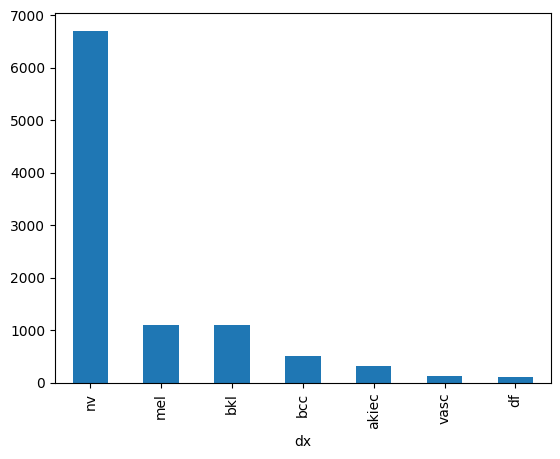

In [ ]:
# Task 1.1 — Load and Explore

print(df.head())
print(df.shape)
print(df.isnull().sum())

df.fillna("Unknown", inplace=True)

print(df["dx"].value_counts())

df["dx"].value_counts().plot(kind="bar")

# If one class has far more samples than the other, note this and use F1-score as your main metric?

If one class has much more data than the other, the dataset is imbalanced. Accuracy can be misleading, so F1-score is used as the main metric because it considers both precision and recall.

# Task 1.2 — Prepare the Data

In [ ]:
# Separate features and label
X = df.drop(columns=["dx"])
y = df["dx"]
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Task 1.3 — Train and Compare Models


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


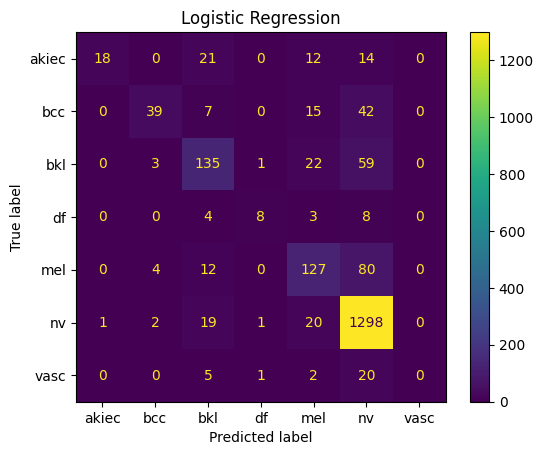

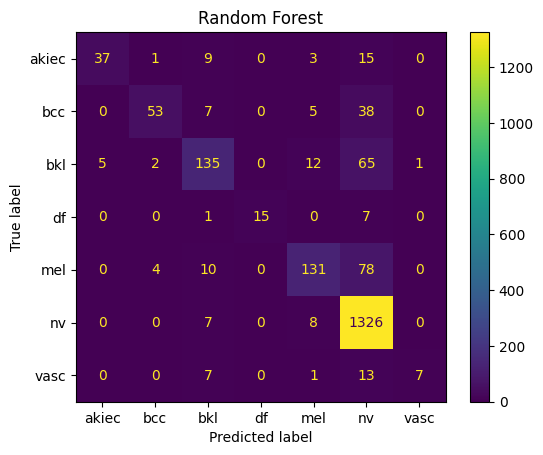

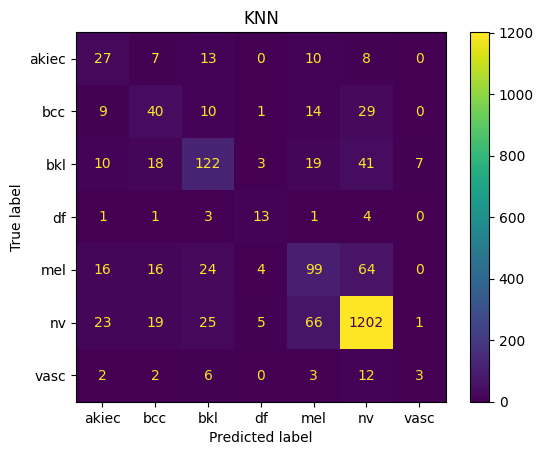

                 Model  Accuracy  Precision    Recall  F1-score
0  Logistic Regression  0.811283   0.795602  0.811283  0.789948
1        Random Forest  0.850724   0.848843  0.850724  0.837285
2                  KNN  0.751872   0.749196  0.751872  0.749578

Best Model:
Model        Random Forest
Accuracy          0.850724
Precision         0.848843
Recall            0.850724
F1-score          0.837285
Name: 1, dtype: object


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

# Prepare data (remove non-numeric columns)
X = df.drop(columns=["dx", "image_id", "lesion_id"], errors="ignore")
y = df["dx"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier()
}

results = []

# Train + evaluate
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, average="weighted"),
        recall_score(y_test, y_pred, average="weighted"),
        f1_score(y_test, y_pred, average="weighted")
    ])

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.title(name)
    plt.show()

# Summary table
results_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Precision", "Recall", "F1-score"
])

print(results_df)

# Best model
best = results_df.loc[results_df["F1-score"].idxmax()]
print("\nBest Model based on F1-score:")
print(best)

• Put all results in one summary table and choose the best model  - explain your choice



Logistic Regression and Random Forest performed best with the highest F1-score (0.579) and accuracy (0.678).
Since the dataset is imbalanced, F1-score is the most important metric, so either of these models is the best choice.